In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure

from vip_slap2_analysis.morphology import (
    load_snt_bundle,
    compute_basic_metrics,
    plot_morphology_triptych,
)

from PNW_cmap import PNW_cmap
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [3]:
target_mice = [
#     803496,
#     804730,804733,810196,
#     809047,803121,
    826033
#     ,838410,
#     834788
]

In [4]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [5]:
all_metrics = []
all_bundles = []
for asset in assets:
    try:
        reconst_path = glob.glob(os.path.join(asset.session_dir,'**','reconstruction','structure**'),recursive=True)[0]
        print(reconst_path)
        bundle = load_snt_bundle(reconst_path)
        metrics = compute_basic_metrics(bundle.tree)
        all_metrics.append(metrics)
        all_bundles.append(bundle)
    except Exception as e:
        print(asset.session_id)
        print(e)
        pass

826033_2026-02-17_13-13-55
list index out of range
826033_2026-02-18_11-57-04
list index out of range
826033_2026-02-19_13-47-57
list index out of range
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\826033_2026-02-21_09-23-34_slap2_2026-02-21_09-23-34\reconstruction\structure_volume_20260221_104501_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21\826033_2026-02-23_10-45-21_slap2_2026-02-23_10-45-21\reconstruction\structure_volume_20260223_114627_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-24_14-14-45\826033_2026-02-24_14-14-45_slap2_2026-02-24_14-14-45\reconstruction\structure_volume_20260224_151043_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-25_08-49-29\826033_2026-02-25_08-49-29_slap2_2026-02-25_08-49-29\reconstruction

In [13]:
for i,bundle in enumerate(all_bundles):
    try:
        reconst_path = glob.glob(os.path.join(assets[i].session_dir,'**','reconstruction','structure**'),recursive=True)[0]
        print(reconst_path)
        fig, axes = plot_morphology_triptych(
            bundle.tree,
            smooth=True,
            save_path_stem=None,
        )
    
        fig.suptitle(f'Cell01 DMD1: {assets[i].session_id}')
        fig.tight_layout()
        filen = 'cell_tryptic'
        save_figure(fig,os.path.join(reconst_path,filen),formats=['.pdf','.png'],dpi=300)
    except:
        print(assets[i].session_id)

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-27_13-53-35\826033_2026-02-27_13-53-35_slap2_2026-02-27_13-53-35\reconstruction\structure_volume_20260227_150709_DMD1-REFERENCE_cell01_reconstruction


<IPython.core.display.Javascript object>


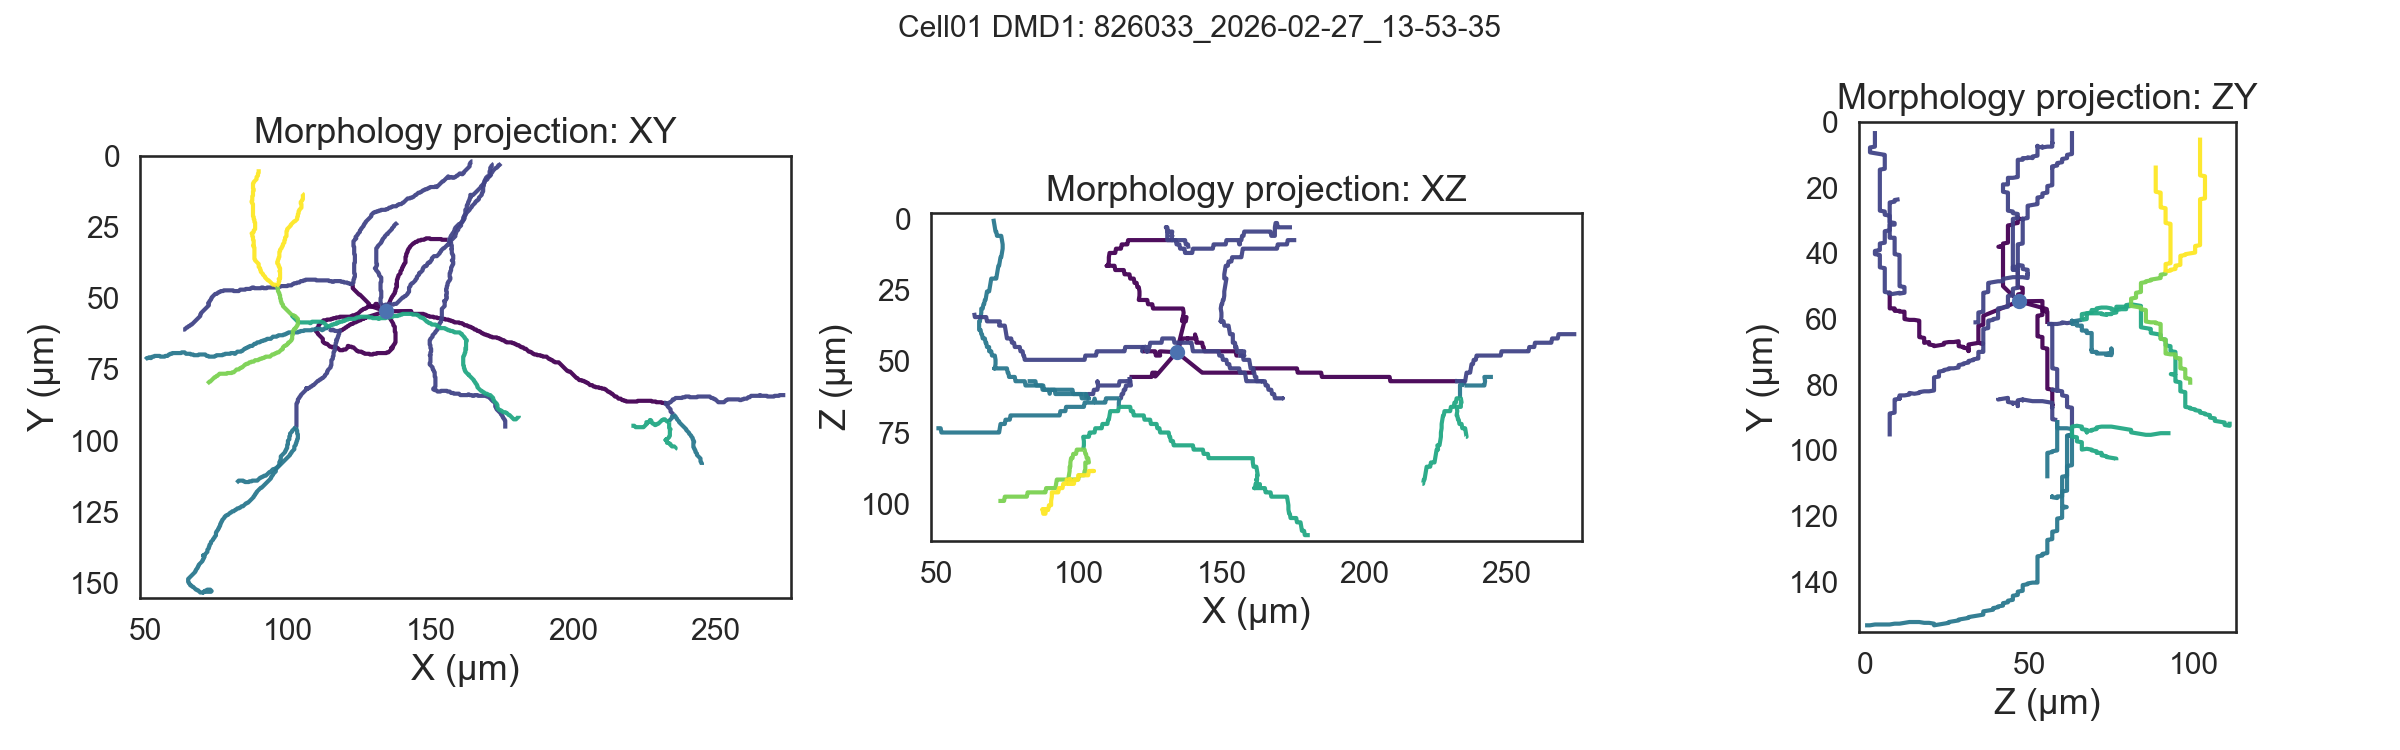

In [17]:
bundle=all_bundles[-1]
reconst_path = glob.glob(os.path.join(assets[-1].session_dir,'**','reconstruction','structure**'),recursive=True)[0]
print(reconst_path)
fig, axes = plot_morphology_triptych(
    bundle.tree,
    smooth=True,
    save_path_stem=None,
)

fig.suptitle(f'Cell01 DMD1: {assets[-1].session_id}')
fig.tight_layout()

filen = 'cell_tryptic'
save_figure(fig,os.path.join(Path(reconst_path).parent,filen),formats=['.pdf','.png'],dpi=300)